In [ ]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if all((candidate / name).exists() for name in ("research", "configs", "runs")):
            return candidate
    raise FileNotFoundError("C:/ronbun 내부에서 노트북을 실행하십시오.")


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 사용자 선택 영역: 모델·데이터셋·완료 run만 바꾸고 아래 로직은 수정하지 않습니다.
# 직접 실행은 매번 아래 기본값으로 초기화하여 이전 커널 상태를 재사용하지 않습니다.
# 배치 runner가 삽입한 parameter cell이 명시적 sentinel을 제공한 경우에만 외부 선택을 보존합니다.
PARAMETERS_INJECTED = globals().get("CROSS_DATASET_REPORT_PARAMETERS_INJECTED") is True
if not PARAMETERS_INJECTED:
    MODEL_NAME = "arcface"
    DATASETS = ("rfw_custom",)
    MODEL_UIDS = {"rfw_custom": "arcface-7972a704552df378345f"}
    RUN_IDS = {"rfw_custom": "20260810-R001-558cd106"}
    INCLUDE_SURVFACE_FAITHFULNESS = True
    WRITE_OUTPUTS = True
    OVERWRITE_COMMON_OUTPUTS = True
    RFW_EVALUATION_DIR = None
    MODEL_RUN_MATRIX = {}
    REQUIRE_COMPLETE_MODEL_MATRIX = False

MODEL_NAME = str(MODEL_NAME)
DATASETS = tuple(DATASETS)
if MODEL_NAME not in {"arcface", "adaface", "magface", "edgeface"}:
    raise ValueError(f"지원하지 않는 MODEL_NAME: {MODEL_NAME!r}")
if not DATASETS or not set(DATASETS).issubset({"lfw", "survface", "rfw_custom"}):
    raise ValueError(f"지원하지 않는 DATASETS: {DATASETS!r}")

# MODEL_UIDS와 RUN_IDS는 각각 model_uid와 Step 4 workflow run_id입니다.
MODEL_UIDS = dict(MODEL_UIDS)
RUN_IDS = dict(RUN_IDS)
selector_keys = set(DATASETS)
for selector_name, selector in (("MODEL_UIDS", MODEL_UIDS), ("RUN_IDS", RUN_IDS)):
    if set(selector) != selector_keys:
        raise ValueError(
            f"{selector_name} keys must exactly match DATASETS: "
            f"datasets={sorted(selector_keys)}, keys={sorted(selector)}"
        )





CHUNKSIZE = 100_000
PREFER_MULTI_FPIR_SEARCH_SPACE = True  # FPIR 10%/1%를 함께 보존한 v4 우선
REQUIRE_HOMOGENEOUS_POSTPROCESSING = True  # 선택 dataset 간 producer/schema 혼합 금지
ALLOW_LEGACY_POSTPROCESSING = False  # 명시적으로 True일 때만 v2/v3/legacy 허용
INCLUDE_SURVFACE_FAITHFULNESS = bool(INCLUDE_SURVFACE_FAITHFULNESS)  # 3-model high/low/random occlusion table
REBUILD_DATASET_SUMMARIES = False  # legacy 대용량 원본에서 다시 집계
VERIFY_SOURCE_SHA256 = False       # True이면 수 GB 원본 SHA-256까지 재검증
WRITE_OUTPUTS = bool(WRITE_OUTPUTS)
OVERWRITE_COMMON_OUTPUTS = bool(OVERWRITE_COMMON_OUTPUTS)
# Optional explicit 4-model × 3-dataset completed-run matrix. Values are run dirs.
MODEL_RUN_MATRIX = dict(MODEL_RUN_MATRIX)
REQUIRE_COMPLETE_MODEL_MATRIX = bool(REQUIRE_COMPLETE_MODEL_MATRIX)

required_relative_paths = (
    Path("COMPLETED"),
    Path("artifacts/step2_workflow/freeze_manifest.json"),
    Path("artifacts/step2_workflow/step4_summary.json"),
    Path("artifacts/step2_workflow/paired_embedding_metrics.csv"),
    Path("artifacts/step2_workflow/retrieval_metrics.csv"),
)
candidate_rows = []
for manifest_path in sorted((PROJECT_ROOT / "runs").rglob("run_manifest.json")):
    run_dir = manifest_path.parent
    freeze_path = run_dir / "artifacts/step2_workflow/freeze_manifest.json"
    step4_path = run_dir / "artifacts/step2_workflow/step4_summary.json"
    if not freeze_path.is_file() or not step4_path.is_file():
        continue
    run_manifest = load_json(manifest_path)
    freeze = load_json(freeze_path)
    step4 = load_json(step4_path)
    model_uid = str(freeze.get("model_uid", ""))
    dataset = str(freeze.get("dataset_id", ""))
    ready = (
        run_manifest.get("status") == "completed"
        and freeze.get("fallback_free") is True
        and all((run_dir / path).exists() for path in required_relative_paths)
        and str(run_manifest.get("run_id")) == str(freeze.get("run_id"))
        and str(step4.get("run_id")) == str(freeze.get("run_id"))
    )
    paired_path = run_dir / "artifacts/step2_workflow/paired_embedding_metrics.csv"
    retrieval_path = run_dir / "artifacts/step2_workflow/retrieval_metrics.csv"
    candidate_rows.append(
        {
            "dataset": dataset,
            "model_name": model_uid.split("-", 1)[0].lower(),
            "model_uid": model_uid,
            "run_id": str(run_manifest.get("run_id", "")),
            "status": run_manifest.get("status"),
            "ready": ready,
            "mode": freeze.get("scope", {}).get("mode"),
            "data_fraction": freeze.get("scope", {}).get("data_fraction"),
            "is_paper_run": freeze.get("scope", {}).get("is_paper_run"),
            "selected_samples": step4.get("selected_samples"),
            "paired_rows": step4.get("paired_rows"),
            "retrieval_rows": step4.get("retrieval_rows"),
            "source_gib": round(
                sum(
                    path.stat().st_size if path.exists() else 0
                    for path in (paired_path, retrieval_path)
                )
                / (1024**3),
                3,
            ),
            "source_branch": run_manifest.get("git", {}).get("branch"),
            "source_commit": run_manifest.get("git", {}).get("commit"),
            "run_dir": run_dir.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

EXPERIMENT_CANDIDATES = pd.DataFrame.from_records(candidate_rows)
if EXPERIMENT_CANDIDATES.empty:
    raise FileNotFoundError("완료된 Step 4 후보를 조회할 수 없습니다.")
EXPERIMENT_CANDIDATES = EXPERIMENT_CANDIDATES.sort_values(
    ["dataset", "model_name", "run_id"]
).reset_index(drop=True)
display(EXPERIMENT_CANDIDATES)

RUN_SELECTORS = {}
try:
    import ipywidgets as widgets

    for dataset in DATASETS:
        choices = EXPERIMENT_CANDIDATES.loc[
            EXPERIMENT_CANDIDATES["ready"]
            & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
            & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
            & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
        ]
        options = [
            (
                f"{row.run_id} | {row.model_uid} | {row.mode} "
                f"p={row.data_fraction}",
                row.run_id,
            )
            for row in choices.itertuples(index=False)
        ]
        values = {value for _, value in options}
        if RUN_IDS[dataset] not in values:
            raise ValueError(
                f"{dataset}: configured run_id {RUN_IDS[dataset]!r}가 "
                "조회된 완료 후보에 없습니다."
            )
        RUN_SELECTORS[dataset] = widgets.Dropdown(
            options=options,
            value=RUN_IDS[dataset],
            description=dataset,
            layout=widgets.Layout(width="900px"),
            style={"description_width": "100px"},
        )
    display(widgets.VBox(list(RUN_SELECTORS.values())))
    print("드롭다운을 변경한 뒤 다음 셀부터 실행하십시오.")
except ImportError:
    print("ipywidgets가 없어 RUN_IDS 설정값을 사용합니다.")
    display(pd.Series(RUN_IDS, name="selected_run_id").to_frame())


,dataset,model_name,model_uid,run_id,status,ready,mode,data_fraction,is_paper_run,selected_samples,paired_rows,retrieval_rows,source_gib,source_branch,source_commit,run_dir
0,lfw,adaface,adaface-4df25b75e065b0b9ed43,20260804-R001-60fc86b5,completed,True,real,1.0,True,13195,131950,75740,0.270,step6,f9ac98001ec0452017f60411c70a391d2d2ab113,runs/lfw_20260804/20260804-R001-60fc86b5_step4...
1,lfw,arcface,arcface-7972a704552df378345f,20260803-R001-a4479011,completed,True,real,1.0,True,13195,131950,75740,0.270,step6,e85a07582d77f7df404b9ad819e84d4d4afa8ab9,runs/lfw_20260803/20260803-R001-a4479011_step4...
2,lfw,arcface,arcface-7972a704552df378345f,20260810-R001-e9b2f0fd,completed,True,real,1.0,True,13195,131950,151480,0.513,step7,ca8496a7e848d6af594b880a30c9821513843391,runs/lfw_20260810/20260810-R001-e9b2f0fd_step4...
3,lfw,edgeface,edgeface-a348c305af33c223b337,20260810-R001-fa945179,completed,True,real,1.0,True,13195,131950,151480,0.511,step7,8d55cd0cc610139e8d2dc4c62c0781b9327725d9,runs/lfw_20260810/20260810-R001-fa945179_step4...
4,lfw,magface,magface-6931178ad2025e1b3799,20260804-R001-325af0c4,completed,True,real,1.0,True,13195,131950,75740,0.269,step6,6c977210a2c1e3e02eaa20c23f8baa1586cfe4af,runs/lfw_20260804/20260804-R001-325af0c4_step4...
5,rfw_custom,adaface,adaface-4df25b75e065b0b9ed43,20260810-R001-26ad700c,completed,True,real,1.0,True,40520,405200,1054410,3.716,step7,62a71cf529b97f54473379bd484065efd3b9858b,runs/rfw_custom_20260810/20260810-R001-26ad700...
6,rfw_custom,arcface,arcface-7972a704552df378345f,20260810-R001-558cd106,completed,True,real,1.0,True,40520,405200,1054410,3.709,step7,ca8496a7e848d6af594b880a30c9821513843391,runs/rfw_custom_20260810/20260810-R001-558cd10...
7,rfw_custom,arcface,arcface-7972a704552df378345f,20260810-R001-cd97c59b,completed,True,real,1.0,True,40520,405200,1054410,3.709,step7,ce913610057d73b0c25afff5eac05414f99625e9,runs/rfw_custom_20260810/20260810-R001-cd97c59...
8,rfw_custom,edgeface,edgeface-a348c305af33c223b337,20260810-R001-49ce74ce,completed,True,real,1.0,True,40520,405200,1054410,3.706,step7,f9e28d9f959ca956f568f281ef33b080ac076d74,runs/rfw_custom_20260810/20260810-R001-49ce74c...
9,rfw_custom,magface,magface-6931178ad2025e1b3799,20260810-R001-5304b105,completed,True,real,1.0,True,40520,405200,1054410,3.711,step7,5ada66a3565cf93a999bc0b56d6cb2bc756b2ece,runs/rfw_custom_20260810/20260810-R001-5304b10...


드롭다운을 변경한 뒤 다음 셀부터 실행하십시오.


# 모델·데이터셋 선택형 compact 결과 보고서

완료된 fallback-free LFW, SurvFace, RFW-Custom Step 4 run을 선택하여 PCA/PQ, open-set DIR/FPIR, Grad-CAM 결합 결과를 검증된 compact artifact로 통합합니다. 단일 checkpoint 상세 보고를 유지하면서, `MODEL_RUN_MATRIX`에 명시한 ArcFace·AdaFace·MagFace·EdgeFace × 3 datasets의 12개 완료 run을 별도 통합 표로 검증합니다. 모델 간 비교는 checkpoint-level 일반화로만 해석합니다.

- `compression_summary.csv`: family/profile당 1행
- `retrieval_summary.csv`: family/profile/search mode/threshold policy/target FPIR당 1행
- `lfw_survface_fpir_appendix.csv`: LFW·SurvFace의 FPIR 10%/1%, false accept/분모/realized FPIR/CI 표
- RFW-Custom 1:N은 open-set 표에 포함하고 RFW-Official 1:1 TAR/FAR/EER는 별도 section에 둡니다.

대용량 query/sample ledger는 복제하지 않으며 source manifest와 SHA-256 lineage를 검증합니다.


In [16]:
from scripts.generate_step4_compact_summaries import generate
from research.evaluation import load_cross_dataset_saliency_associations
from research.runtime.hashing import sha256_file

SELECTED_RUN_IDS = {
    dataset: RUN_SELECTORS[dataset].value if RUN_SELECTORS else RUN_IDS[dataset]
    for dataset in DATASETS
}

selected_rows = []
SELECTED_RUNS = {}
for dataset in DATASETS:
    matches = EXPERIMENT_CANDIDATES.loc[
        EXPERIMENT_CANDIDATES["ready"]
        & EXPERIMENT_CANDIDATES["dataset"].eq(dataset)
        & EXPERIMENT_CANDIDATES["model_name"].eq(MODEL_NAME)
        & EXPERIMENT_CANDIDATES["model_uid"].eq(MODEL_UIDS[dataset])
        & EXPERIMENT_CANDIDATES["run_id"].eq(SELECTED_RUN_IDS[dataset])
    ]
    if len(matches) != 1:
        raise ValueError(
            f"{dataset}: 선택 조건과 일치하는 완료 실행이 1개가 아닙니다: {len(matches)}"
        )
    row = matches.iloc[0]
    run_dir = PROJECT_ROOT / str(row["run_dir"])
    SELECTED_RUNS[dataset] = run_dir
    selected_rows.append(row)

selected_run_table = pd.DataFrame(selected_rows).reset_index(drop=True)
if set(selected_run_table["model_name"]) != {MODEL_NAME}:
    raise ValueError("선택 실행의 model_name이 MODEL_NAME과 일치하지 않습니다.")
display(selected_run_table)

SALIENCY_ASSOCIATIONS = load_cross_dataset_saliency_associations(
    SELECTED_RUNS,
    expected_model_uids={dataset: MODEL_UIDS[dataset] for dataset in DATASETS},
    expected_run_ids=SELECTED_RUN_IDS,
)
SALIENCY_GEOMETRY_ALL = SALIENCY_ASSOCIATIONS.geometry
SALIENCY_RETRIEVAL_ALL = SALIENCY_ASSOCIATIONS.retrieval
REPRESENTATIVE_CASES_ALL = SALIENCY_ASSOCIATIONS.representative_cases
display(pd.DataFrame([{
    "geometry_association_rows": len(SALIENCY_GEOMETRY_ALL),
    "retrieval_association_rows": len(SALIENCY_RETRIEVAL_ALL),
    "representative_case_rows": len(REPRESENTATIVE_CASES_ALL),
}]))

SURVFACE_ORIGIN_AUDIT = pd.DataFrame()
SURVFACE_CALIBRATION_TRANSFER_FAILED = None
cross_model_audit_path = (
    PROJECT_ROOT / "runs/survface_origin_fpir_diagnostics"
    / "20260802_cross_model_summary_v1/cross_model_origin_fpir_summary.csv"
)
if "survface" in DATASETS and cross_model_audit_path.is_file():
    cross_model_audit = pd.read_csv(cross_model_audit_path)
    SURVFACE_ORIGIN_AUDIT = cross_model_audit.loc[
        cross_model_audit["model_uid"].eq(MODEL_UIDS["survface"])
        & cross_model_audit["source_run_id"].eq(SELECTED_RUN_IDS["survface"])
    ].copy()
    if not SURVFACE_ORIGIN_AUDIT.empty:
        SURVFACE_CALIBRATION_TRANSFER_FAILED = bool(
            (SURVFACE_ORIGIN_AUDIT["test_fpir"] > SURVFACE_ORIGIN_AUDIT["target_fpir"]).any()
        )
        display(
            SURVFACE_ORIGIN_AUDIT[[
                "model_family", "calibration_condition_uid",
                "calibration_fpir", "matched_test_fpir", "test_fpir",
                "test_to_target_fpir_ratio",
            ]]
        )
        if SURVFACE_CALIBRATION_TRANSFER_FAILED:
            print("WARNING: SurvFace threshold-dependent claim은 calibration transfer 실패로 보류됩니다.")


,dataset,model_name,model_uid,run_id,status,ready,mode,data_fraction,is_paper_run,selected_samples,paired_rows,retrieval_rows,source_gib,source_branch,source_commit,run_dir
0,survface,arcface,arcface-7972a704552df378345f,20260810-R001-5d742943,completed,True,real,1.0,True,463341,4633410,12751130,48.476,step7,ca8496a7e848d6af594b880a30c9821513843391,runs/survface_20260810/20260810-R001-5d742943_...


,geometry_association_rows,retrieval_association_rows,representative_case_rows
0,570,7980,953


## 1. 데이터셋별 compact summary 생성·검증

기본값은 검증된 `search_space_v4_multi_fpir`만 사용합니다. 동일 PCA/PQ 검색 점수에 FPIR 10%와 1% threshold를 적용하고 PCA direct/reconstruction과 PQ reconstruction/ADC를 분리합니다. RFW-Custom도 같은 compact producer를 사용하지만 RFW-Official pair benchmark와 artifact/protocol UID를 공유하지 않습니다.


In [17]:
def resolve_manifest_path(recorded_path: str) -> Path:
    path = Path(recorded_path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def validate_summary_bundle(
    summary_dir: Path,
    *,
    dataset: str,
    run_dir: Path,
) -> dict:
    manifest_path = summary_dir / "summary_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(manifest_path)
    payload = load_json(manifest_path)
    artifact_type = str(payload.get("artifact_type", ""))
    supported_artifacts = {
        "step4_search_space_multi_fpir_v4",
        *(
            {"step4_compact_summaries", "step4_search_space_refresh"}
            if ALLOW_LEGACY_POSTPROCESSING
            else set()
        ),
    }
    if artifact_type not in supported_artifacts:
        raise ValueError(f"{dataset}: unsupported summary artifact: {artifact_type!r}")
    expected_identity = {
        "dataset_id": dataset,
        "model_uid": MODEL_UIDS[dataset],
        "run_id": SELECTED_RUN_IDS[dataset],
    }
    if artifact_type == "step4_compact_summaries":
        expected_identity["source_run_status"] = "completed"
    else:
        expected_identity["source_run_id"] = SELECTED_RUN_IDS[dataset]
        if payload.get("source_run_preserved_immutable") is not True:
            raise ValueError(f"{dataset}: derived summary did not preserve source run")
    if artifact_type == "step4_search_space_multi_fpir_v4":
        if payload.get("schema_version") != 4:
            raise ValueError(f"{dataset}: v4 schema version mismatch")
        if payload.get("producer_script") != "scripts/refresh_step4_search_spaces.py":
            raise ValueError(f"{dataset}: unexpected v4 producer")
        observed_targets = {float(value) for value in payload.get("target_fpirs", [])}
        if observed_targets != {0.10, 0.01}:
            raise ValueError(f"{dataset}: FPIR 10%/1% coverage mismatch")
        for family in ("pca", "pq"):
            family_entry = payload.get("family_manifests", {}).get(family, {})
            family_path = resolve_manifest_path(str(family_entry.get("path", "")))
            if not family_path.is_file():
                raise FileNotFoundError(family_path)
            if sha256_file(family_path) != family_entry.get("sha256"):
                raise ValueError(f"{dataset}/{family}: family manifest SHA-256 mismatch")
            family_payload = load_json(family_path)
            diagnostics = family_payload.get("outputs", {}).get(
                "origin_calibration_diagnostics.json", {}
            )
            diagnostics_path = family_path.parent / str(diagnostics.get("path", ""))
            if not diagnostics_path.is_file():
                raise FileNotFoundError(diagnostics_path)
            if sha256_file(diagnostics_path) != diagnostics.get("sha256"):
                raise ValueError(f"{dataset}/{family}: diagnostics SHA-256 mismatch")

    mismatches = {
        key: (payload.get(key), expected)
        for key, expected in expected_identity.items()
        if payload.get(key) != expected
    }
    if mismatches:
        raise ValueError(f"{dataset}: summary identity mismatch: {mismatches}")

    source_manifest = payload.get("source_files", {}).get("run_manifest.json", {})
    recorded_source = resolve_manifest_path(str(source_manifest.get("path", "")))
    if recorded_source.resolve() != (run_dir / "run_manifest.json").resolve():
        raise ValueError(f"{dataset}: summary가 선택하지 않은 source run을 참조합니다.")

    output_files = payload.get("output_files", {})
    if set(output_files) != {"compression_summary.csv", "retrieval_summary.csv"}:
        raise ValueError(f"{dataset}: summary output file contract mismatch")
    for name, metadata in output_files.items():
        path = summary_dir / name
        if not path.is_file():
            raise FileNotFoundError(path)
        if path.stat().st_size != int(metadata["bytes"]):
            raise ValueError(f"{dataset}/{name}: byte-size mismatch")
        if sha256_file(path) != metadata["sha256"]:
            raise ValueError(f"{dataset}/{name}: SHA-256 mismatch")

    if VERIFY_SOURCE_SHA256:
        for name, metadata in payload.get("source_files", {}).items():
            path = resolve_manifest_path(str(metadata["path"]))
            if path.stat().st_size != int(metadata["bytes"]):
                raise ValueError(f"{dataset}/{name}: source byte-size mismatch")
            if sha256_file(path) != metadata["sha256"]:
                raise ValueError(f"{dataset}/{name}: source SHA-256 mismatch")
    return payload


SUMMARY_DIRS = {}
SUMMARY_MANIFESTS = {}
generation_rows = []
for dataset, run_dir in SELECTED_RUNS.items():
    result_base = (
        PROJECT_ROOT
        / "results"
        / "paper"
        / dataset
        / SELECTED_RUN_IDS[dataset]
    )
    multi_fpir_search_space_dir = result_base / "search_space_v4_multi_fpir"
    matched_search_space_dir = result_base / "search_space_v3_matched_calibration"
    legacy_search_space_dir = result_base / "search_space_v2"
    legacy_summary_dir = result_base / "summaries"
    use_multi_fpir_search_space = bool(
        PREFER_MULTI_FPIR_SEARCH_SPACE
        and (multi_fpir_search_space_dir / "summary_manifest.json").is_file()
    )
    if not use_multi_fpir_search_space and not ALLOW_LEGACY_POSTPROCESSING:
        raise FileNotFoundError(
            f"{dataset}: 검증된 search_space_v4_multi_fpir가 없습니다. "
            "완료 run에서 통합 postprocessing을 먼저 실행하십시오."
        )
    use_matched_search_space = bool(
        ALLOW_LEGACY_POSTPROCESSING
        and not use_multi_fpir_search_space
        and (matched_search_space_dir / "summary_manifest.json").is_file()
    )
    use_legacy_search_space = bool(
        ALLOW_LEGACY_POSTPROCESSING
        and not use_multi_fpir_search_space
        and not use_matched_search_space
        and (legacy_search_space_dir / "summary_manifest.json").is_file()
    )
    use_search_space = (
        use_multi_fpir_search_space
        or use_matched_search_space
        or use_legacy_search_space
    )
    summary_dir = (
        multi_fpir_search_space_dir
        if use_multi_fpir_search_space
        else matched_search_space_dir
        if use_matched_search_space
        else legacy_search_space_dir
        if use_legacy_search_space
        else legacy_summary_dir
    )
    SUMMARY_DIRS[dataset] = summary_dir
    expected_outputs = tuple(
        summary_dir / name
        for name in (
            "compression_summary.csv",
            "retrieval_summary.csv",
            "summary_manifest.json",
        )
    )
    present_count = sum(path.exists() for path in expected_outputs)
    should_generate = (not use_search_space) and (
        REBUILD_DATASET_SUMMARIES or present_count == 0
    )
    if 0 < present_count < len(expected_outputs) and not REBUILD_DATASET_SUMMARIES:
        raise RuntimeError(
            f"{dataset}: 일부 summary만 존재합니다. 원인을 확인한 뒤 "
            "REBUILD_DATASET_SUMMARIES=True로 재생성하십시오."
        )
    if should_generate:
        result = generate(
            run_dir,
            summary_dir,
            chunksize=CHUNKSIZE,
            overwrite=REBUILD_DATASET_SUMMARIES,
        )
        action = "generated"
    else:
        result = {"output_dir": str(summary_dir)}
        action = (
            "reused_search_space_v4_multi_fpir"
            if use_multi_fpir_search_space
            else "reused_search_space_v3_matched_calibration"
            if use_matched_search_space
            else "reused_search_space_v2"
            if use_legacy_search_space
            else "reused_legacy"
        )
    payload = validate_summary_bundle(
        summary_dir,
        dataset=dataset,
        run_dir=run_dir,
    )
    SUMMARY_MANIFESTS[dataset] = payload
    generation_rows.append(
        {
            "dataset": dataset,
            "action": action,
            "run_id": payload["run_id"],
            "model_uid": payload["model_uid"],
            "artifact_type": payload["artifact_type"],
            "claim_status": payload.get("claim_status", "legacy_source_run"),
            **payload["validated_counts"],
            "summary_dir": summary_dir.relative_to(PROJECT_ROOT).as_posix(),
        }
    )

if REQUIRE_HOMOGENEOUS_POSTPROCESSING:
    artifact_types = {payload.get("artifact_type") for payload in SUMMARY_MANIFESTS.values()}
    if artifact_types != {"step4_search_space_multi_fpir_v4"}:
        raise ValueError(f"postprocessing artifact 혼합 또는 구형 artifact: {artifact_types}")

if "survface" in SUMMARY_MANIFESTS:
    matched_signatures = SUMMARY_MANIFESTS["survface"].get(
        "origin_calibration_signatures", {}
    )
    SURVFACE_CALIBRATION_TRANSFER_FAILED = any(
        signature.get("status") != "target_met"
        for signature in matched_signatures.values()
    )
    for target, signature in matched_signatures.items():
        print(
            f"SurvFace FPIR target {target}:", signature.get("status"),
            "test_fpir=", signature.get("test_fpir"),
        )
generation_table = pd.DataFrame(generation_rows)
display(generation_table)


SurvFace FPIR target 0.1: target_met test_fpir= 0.09269238351843333
SurvFace FPIR target 0.01: failed_target_fpir test_fpir= 0.012412104882696983


,dataset,action,run_id,model_uid,artifact_type,claim_status,compression_summary_rows,retrieval_summary_rows,summary_dir
0,survface,reused_search_space_v4_multi_fpir,20260810-R001-5d742943,arcface-7972a704552df378345f,step4_search_space_multi_fpir_v4,validation_required,10,70,results/paper/survface/20260810-R001-5d742943/...


## 2. summary schema·값 범위·CI 검증과 결합

결합 grain은 dataset/model/run/compression profile/search mode/threshold policy/target FPIR당 1행입니다. false accept 수와 분모, realized FPIR, Wilson 95% CI, compressed-minus-origin 변화와 paired-bootstrap 95% CI를 fail-closed로 확인합니다.


In [18]:
def normalize_retrieval_summary(
    frame: pd.DataFrame, *, legacy_target_fpir: float
) -> pd.DataFrame:
    result = frame.copy()
    if "search_mode" not in result:
        result["search_mode"] = result["compression_family"].map(
            {"pca": "pca_direct_cosine", "pq": "pq_reconstruction_cosine"}
        )
    defaults = {
        "target_fpir": legacy_target_fpir,
        "origin_score_space": "cosine_similarity",
        "compressed_score_space": "cosine_similarity",
        "score_spaces_comparable": True,
        "frozen_origin_threshold_applicable": True,
        "gallery_template_count": pd.NA,
        "origin_storage_bytes_per_embedding": 512 * 4,
        "origin_gallery_storage_bytes": pd.NA,
        "compressed_gallery_storage_bytes": pd.NA,
        "amortized_storage_bytes_per_gallery_template": pd.NA,
        "compressed_search_latency_ms_total": pd.NA,
        "compressed_search_latency_ms_per_query": pd.NA,
        "compressed_search_queries_per_second": pd.NA,
        "accept_to_reject_count": pd.NA,
        "accept_to_reject_rate": pd.NA,
        "reject_to_accept_count": pd.NA,
        "reject_to_accept_rate": pd.NA,
    }
    for column, value in defaults.items():
        if column not in result:
            result[column] = value
    return result


compression_required = {
    "dataset", "model_uid", "run_id", "extraction_uid",
    "origin_embedding_artifact_uid", "compression_family",
    "compression_profile", "sample_count", "mean_angular_error_rad",
    "p95_angular_error_rad", "mean_cosine_to_origin",
    "storage_bytes_per_embedding", "codebook_bytes",
    "codebook_bytes_source", "origin_fallback_count",
}
retrieval_required = {
    "dataset", "model_uid", "run_id", "extraction_uid",
    "origin_embedding_artifact_uid", "protocol_uid",
    "compression_family", "compression_profile", "search_mode",
    "threshold_policy", "target_fpir", "origin_score_space", "compressed_score_space",
    "score_spaces_comparable", "frozen_origin_threshold_applicable",
    "query_count", "mated_count", "non_mated_count",
    "origin_decision_threshold", "compressed_decision_threshold",
    "origin_dir_rank1", "compressed_dir_rank1",
    "origin_fpir", "compressed_fpir", "agreement_with_origin_rate",
    "threshold_crossing_rate", "storage_bytes_per_embedding",
    "codebook_bytes", "codebook_bytes_source", "origin_fallback_count",
    "gallery_template_count", "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
    "compressed_search_latency_ms_per_query",
    "compressed_search_queries_per_second",
    "origin_false_accept_count", "compressed_false_accept_count",
    "origin_fpir_denominator", "compressed_fpir_denominator",
    "origin_realized_fpir", "compressed_realized_fpir",
    "origin_fpir_wilson95_low", "origin_fpir_wilson95_high",
    "compressed_fpir_wilson95_low", "compressed_fpir_wilson95_high",
    "origin_dir_rank1_wilson95_low", "origin_dir_rank1_wilson95_high",
    "compressed_dir_rank1_wilson95_low", "compressed_dir_rank1_wilson95_high",
    "compressed_minus_origin_fpir",
    "compressed_minus_origin_fpir_paired_bootstrap95_low",
    "compressed_minus_origin_fpir_paired_bootstrap95_high",
    "compressed_minus_origin_dir_rank1",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
    "confidence_interval_unit", "rate_confidence_interval_method",
    "difference_confidence_interval_method",
    "difference_confidence_interval_resamples",
    "difference_confidence_interval_random_seed",
}
compression_frames = []
retrieval_frames = []
for dataset, summary_dir in SUMMARY_DIRS.items():
    compression = pd.read_csv(summary_dir / "compression_summary.csv")
    retrieval = normalize_retrieval_summary(
        pd.read_csv(summary_dir / "retrieval_summary.csv"),
        legacy_target_fpir=0.10 if dataset in {"survface", "rfw_custom"} else 0.01,
    )
    missing_compression = sorted(compression_required - set(compression.columns))
    missing_retrieval = sorted(retrieval_required - set(retrieval.columns))
    if missing_compression or missing_retrieval:
        raise ValueError(
            f"{dataset}: missing columns: "
            f"compression={missing_compression}, retrieval={missing_retrieval}"
        )
    if not compression["dataset"].eq(dataset).all() or not retrieval["dataset"].eq(dataset).all():
        raise ValueError(f"{dataset}: dataset column mismatch")
    if not compression["model_uid"].eq(MODEL_UIDS[dataset]).all() or not retrieval["model_uid"].eq(MODEL_UIDS[dataset]).all():
        raise ValueError(f"{dataset}: model_uid column mismatch")
    if not compression["run_id"].eq(SELECTED_RUN_IDS[dataset]).all() or not retrieval["run_id"].eq(SELECTED_RUN_IDS[dataset]).all():
        raise ValueError(f"{dataset}: run_id column mismatch")
    if (compression["origin_fallback_count"] != 0).any() or (retrieval["origin_fallback_count"] != 0).any():
        raise ValueError(f"{dataset}: origin fallback row was detected")

    for column in (
        "origin_dir_rank1", "compressed_dir_rank1", "origin_fpir",
        "compressed_fpir", "agreement_with_origin_rate",
        "threshold_crossing_rate",
    ):
        if not retrieval[column].dropna().between(0.0, 1.0).all():
            raise ValueError(f"{dataset}/{column}: value outside [0, 1]")
    if (compression["mean_angular_error_rad"].dropna() < 0).any():
        raise ValueError(f"{dataset}: negative angular error")
    if retrieval["confidence_interval_unit"].ne("probe").any():
        raise ValueError(f"{dataset}: confidence interval unit must be probe")
    if retrieval["rate_confidence_interval_method"].ne("wilson_score").any():
        raise ValueError(f"{dataset}: rate CI must use Wilson score")
    if retrieval["difference_confidence_interval_method"].ne(
        "paired_nonparametric_bootstrap_percentile"
    ).any():
        raise ValueError(f"{dataset}: delta CI must use paired bootstrap")
    if pd.to_numeric(
        retrieval["difference_confidence_interval_resamples"], errors="raise"
    ).ne(2000).any():
        raise ValueError(f"{dataset}: paired bootstrap must use 2000 repeats")
    if pd.to_numeric(
        retrieval["difference_confidence_interval_random_seed"], errors="raise"
    ).ne(42).any():
        raise ValueError(f"{dataset}: paired bootstrap must use seed 42")
    for side in ("origin", "compressed"):
        false_accepts = pd.to_numeric(
            retrieval[f"{side}_false_accept_count"], errors="raise"
        )
        denominator = pd.to_numeric(
            retrieval[f"{side}_fpir_denominator"], errors="raise"
        )
        realized = pd.to_numeric(
            retrieval[f"{side}_realized_fpir"], errors="raise"
        )
        if (denominator <= 0).any() or (false_accepts < 0).any():
            raise ValueError(f"{dataset}: invalid false-accept count/denominator")
        if not ((false_accepts / denominator - realized).abs() <= 1e-12).all():
            raise ValueError(f"{dataset}: realized FPIR does not reconcile")
        if not (realized - retrieval[f"{side}_fpir"]).abs().le(1e-12).all():
            raise ValueError(f"{dataset}: realized FPIR alias drifted")
        for metric in ("fpir", "dir_rank1"):
            rate = pd.to_numeric(retrieval[f"{side}_{metric}"], errors="raise")
            low = pd.to_numeric(
                retrieval[f"{side}_{metric}_wilson95_low"], errors="raise"
            )
            high = pd.to_numeric(
                retrieval[f"{side}_{metric}_wilson95_high"], errors="raise"
            )
            if ((low > rate) | (rate > high)).any():
                raise ValueError(f"{dataset}: {side} {metric} escaped Wilson CI")
    adc = retrieval["search_mode"].eq("pq_adc_exhaustive")
    invalid_adc_policy = adc & retrieval["threshold_policy"].eq("frozen_origin")
    if invalid_adc_policy.any():
        raise ValueError(f"{dataset}: PQ ADC에 frozen-origin threshold가 적용되었습니다.")
    if (adc & retrieval["score_spaces_comparable"].astype(bool)).any():
        raise ValueError(f"{dataset}: PQ ADC score space가 cosine과 비교 가능하다고 표시되었습니다.")

    compression_key = [
        "dataset", "model_uid", "run_id", "compression_family",
        "compression_profile",
    ]
    retrieval_key = [
        *compression_key, "search_mode", "threshold_policy", "target_fpir"
    ]
    if compression.duplicated(compression_key).any():
        raise ValueError(f"{dataset}: duplicate compression summary key")
    if retrieval.duplicated(retrieval_key).any():
        raise ValueError(f"{dataset}: duplicate retrieval summary key")
    if set(compression["compression_profile"]) != set(retrieval["compression_profile"]):
        raise ValueError(f"{dataset}: compression/retrieval profile set mismatch")
    storage_columns = [
        "compression_family", "compression_profile",
        "storage_bytes_per_embedding", "codebook_bytes",
        "codebook_bytes_source",
    ]
    profile_storage = compression[storage_columns].drop_duplicates().sort_values(
        storage_columns
    ).reset_index(drop=True)
    retrieval_storage = retrieval[storage_columns].drop_duplicates().sort_values(
        storage_columns
    ).reset_index(drop=True)
    if not profile_storage.equals(retrieval_storage):
        raise ValueError(f"{dataset}: profile_storage schema mismatch")
    summary_manifest = SUMMARY_MANIFESTS[dataset]
    for frame in (compression, retrieval):
        frame["summary_artifact_type"] = summary_manifest["artifact_type"]
        frame["summary_claim_status"] = summary_manifest.get(
            "claim_status", "legacy_source_run"
        )
        frame["derived_evaluation_paper_eligible"] = summary_manifest.get(
            "derived_evaluation_paper_eligible", pd.NA
        )
    compression_frames.append(compression)
    retrieval_frames.append(retrieval)

compression_profile_all = pd.concat(compression_frames, ignore_index=True)
retrieval_summary_all = pd.concat(retrieval_frames, ignore_index=True)

join_keys = [
    "dataset", "model_uid", "run_id", "summary_artifact_type",
    "summary_claim_status", "derived_evaluation_paper_eligible",
    "extraction_uid",
    "origin_embedding_artifact_uid", "compression_family",
    "compression_profile", "storage_bytes_per_embedding",
    "codebook_bytes", "codebook_bytes_source",
]
compression_for_join = compression_profile_all.rename(
    columns={"origin_fallback_count": "compression_origin_fallback_count"}
)
retrieval_for_join = retrieval_summary_all.rename(
    columns={"origin_fallback_count": "retrieval_origin_fallback_count"}
)
compression_summary_all = compression_for_join.merge(
    retrieval_for_join,
    on=join_keys,
    how="inner",
    validate="one_to_many",
).sort_values(
    [
        "dataset", "target_fpir", "search_mode", "threshold_policy",
        "compression_family",
        "storage_bytes_per_embedding", "compression_profile",
    ]
).reset_index(drop=True)

if len(compression_summary_all) != len(retrieval_summary_all):
    raise ValueError("summary join dropped or duplicated retrieval rows")
display(
    compression_summary_all[
        [
            "dataset", "model_uid", "run_id", "compression_family",
            "compression_profile", "search_mode", "threshold_policy",
            "target_fpir",
            "compressed_score_space", "storage_bytes_per_embedding",
            "amortized_storage_bytes_per_gallery_template",
            "mean_angular_error_rad",
            "compressed_dir_rank1", "compressed_fpir",
            "compressed_dir_rank1_wilson95_low", "compressed_dir_rank1_wilson95_high",
            "compressed_fpir_wilson95_low", "compressed_fpir_wilson95_high",
            "compressed_minus_origin_dir_rank1",
            "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
            "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
            "compressed_minus_origin_fpir",
            "compressed_minus_origin_fpir_paired_bootstrap95_low",
            "compressed_minus_origin_fpir_paired_bootstrap95_high",
            "agreement_with_origin_rate", "threshold_crossing_rate",
            "compressed_search_latency_ms_per_query",
            "compressed_search_queries_per_second",
        ]
    ]
)


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,threshold_policy,target_fpir,compressed_score_space,storage_bytes_per_embedding,...,compressed_minus_origin_dir_rank1,compressed_minus_origin_dir_rank1_paired_bootstrap95_low,compressed_minus_origin_dir_rank1_paired_bootstrap95_high,compressed_minus_origin_fpir,compressed_minus_origin_fpir_paired_bootstrap95_low,compressed_minus_origin_fpir_paired_bootstrap95_high,agreement_with_origin_rate,threshold_crossing_rate,compressed_search_latency_ms_per_query,compressed_search_queries_per_second
0,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_32,pca_direct_cosine,frozen_origin,0.01,cosine_similarity,128,...,0.000463,0.000132,0.000778,0.004181,0.003508,0.004879,0.190136,0.015432,0.187786,5325.208039
1,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_64,pca_direct_cosine,frozen_origin,0.01,cosine_similarity,256,...,-0.000463,-0.000695,-0.000248,-0.007286,-0.007853,-0.006728,0.289006,0.010656,0.182402,5482.409989
2,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_128,pca_direct_cosine,frozen_origin,0.01,cosine_similarity,512,...,-0.000612,-0.000827,-0.000414,-0.010391,-0.010975,-0.009833,0.363951,0.010820,0.181356,5514.007885
3,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_256,pca_direct_cosine,frozen_origin,0.01,cosine_similarity,1024,...,-0.000645,-0.000861,-0.000447,-0.011796,-0.012437,-0.011213,0.417350,0.011973,0.190786,5241.466216
4,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_384,pca_direct_cosine,frozen_origin,0.01,cosine_similarity,1536,...,-0.000645,-0.000861,-0.000447,-0.011821,-0.012461,-0.011221,0.419540,0.011995,0.192702,5189.353072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m8_b8,pq_reconstruction_cosine,recalibrated_compressed,0.10,cosine_similarity,8,...,-0.005892,-0.006570,-0.005279,0.007927,0.006185,0.009537,0.094352,0.086540,0.194291,5146.913179
66,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m16_b8,pq_reconstruction_cosine,recalibrated_compressed,0.10,cosine_similarity,16,...,-0.004849,-0.005478,-0.004236,0.005742,0.004354,0.007221,0.164658,0.066371,0.190538,5248.310286
67,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m32_b8,pq_reconstruction_cosine,recalibrated_compressed,0.10,cosine_similarity,32,...,-0.004353,-0.004932,-0.003757,0.000723,-0.000534,0.002013,0.258884,0.050341,0.195679,5110.410383
68,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m64_b8,pq_reconstruction_cosine,recalibrated_compressed,0.10,cosine_similarity,64,...,-0.002714,-0.003244,-0.002218,-0.000912,-0.001898,0.000124,0.403494,0.033246,0.189135,5287.219240


## 3. 4 checkpoints × 3 open-set datasets 통합 비교

`MODEL_RUN_MATRIX`에 ArcFace·AdaFace·MagFace·EdgeFace 각각의 LFW·SurvFace·RFW-Custom 완료 run directory를 명시하면 12개 v4 compact artifact의 lineage, SHA-256, FPIR 10%/1%, CI 계약을 함께 검증합니다. 자동 latest 선택은 금지하며 결과는 checkpoint-level generalization으로만 해석합니다.


In [19]:
from research.experiments.cross_model_matrix import (
    load_cross_model_open_set_matrix,
    write_cross_model_open_set_matrix,
)

CROSS_MODEL_MATRIX = None
CROSS_MODEL_COMPRESSION = pd.DataFrame()
CROSS_MODEL_RETRIEVAL = pd.DataFrame()
CROSS_MODEL_JOINED = pd.DataFrame()
CROSS_MODEL_SELECTION_MANIFEST = None
if MODEL_RUN_MATRIX:
    CROSS_MODEL_MATRIX = load_cross_model_open_set_matrix(
        MODEL_RUN_MATRIX,
        project_root=PROJECT_ROOT,
    )
    CROSS_MODEL_COMPRESSION = CROSS_MODEL_MATRIX.compression_summary
    CROSS_MODEL_RETRIEVAL = CROSS_MODEL_MATRIX.retrieval_summary
    CROSS_MODEL_JOINED = CROSS_MODEL_MATRIX.joined_summary
    CROSS_MODEL_SELECTION_MANIFEST = CROSS_MODEL_MATRIX.selection_manifest
    display(
        CROSS_MODEL_JOINED[[
            "model_family", "dataset", "compression_family",
            "compression_profile", "search_mode",
            "threshold_policy", "target_fpir",
            "compressed_dir_rank1", "compressed_fpir",
            "compressed_minus_origin_dir_rank1",
            "compressed_minus_origin_fpir",
        ]]
    )
elif REQUIRE_COMPLETE_MODEL_MATRIX:
    raise RuntimeError(
        "REQUIRE_COMPLETE_MODEL_MATRIX=True이지만 MODEL_RUN_MATRIX가 비어 있습니다."
    )
else:
    print(
        "4×3 matrix preview only: 12개 완료 run을 MODEL_RUN_MATRIX에 명시하십시오."
    )


4×3 matrix preview only: 12개 완료 run을 MODEL_RUN_MATRIX에 명시하십시오.


## 4. LFW·SurvFace FPIR 10%/1% appendix

동일 검색 점수에서 두 operating point를 비교합니다. RFW-Custom은 별도 open-set 결과에 남기되 이 공통 appendix의 범위는 요청대로 LFW와 SurvFace입니다. CI 단위는 probe이며 checkpoint 불확실성을 나타내지 않습니다.


In [20]:
APPENDIX_DATASETS = tuple(
    dataset for dataset in ("lfw", "survface") if dataset in DATASETS
)
appendix_columns = [
    "dataset", "model_uid", "run_id", "compression_family",
    "compression_profile", "search_mode", "threshold_policy", "target_fpir",
    "origin_false_accept_count", "origin_fpir_denominator",
    "origin_realized_fpir", "origin_fpir_wilson95_low", "origin_fpir_wilson95_high",
    "compressed_false_accept_count", "compressed_fpir_denominator",
    "compressed_realized_fpir", "compressed_fpir_wilson95_low",
    "compressed_fpir_wilson95_high", "origin_dir_rank1",
    "origin_dir_rank1_wilson95_low", "origin_dir_rank1_wilson95_high",
    "compressed_dir_rank1", "compressed_dir_rank1_wilson95_low",
    "compressed_dir_rank1_wilson95_high", "compressed_minus_origin_fpir",
    "compressed_minus_origin_fpir_paired_bootstrap95_low",
    "compressed_minus_origin_fpir_paired_bootstrap95_high",
    "compressed_minus_origin_dir_rank1",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
]
lfw_survface_fpir_appendix = retrieval_summary_all.loc[
    retrieval_summary_all["dataset"].isin(APPENDIX_DATASETS)
    & retrieval_summary_all["target_fpir"].isin((0.10, 0.01)),
    appendix_columns,
].sort_values(
    ["dataset", "target_fpir", "compression_family", "compression_profile",
     "search_mode", "threshold_policy"],
    kind="stable",
).reset_index(drop=True)
for dataset in APPENDIX_DATASETS:
    observed = set(
        lfw_survface_fpir_appendix.loc[
            lfw_survface_fpir_appendix["dataset"].eq(dataset), "target_fpir"
        ].astype(float)
    )
    if observed != {0.10, 0.01}:
        raise ValueError(f"{dataset}: appendix FPIR 10%/1% coverage mismatch: {observed}")
display(lfw_survface_fpir_appendix)


,dataset,model_uid,run_id,compression_family,compression_profile,search_mode,threshold_policy,target_fpir,origin_false_accept_count,origin_fpir_denominator,...,origin_dir_rank1_wilson95_high,compressed_dir_rank1,compressed_dir_rank1_wilson95_low,compressed_dir_rank1_wilson95_high,compressed_minus_origin_fpir,compressed_minus_origin_fpir_paired_bootstrap95_low,compressed_minus_origin_fpir_paired_bootstrap95_high,compressed_minus_origin_dir_rank1,compressed_minus_origin_dir_rank1_paired_bootstrap95_low,compressed_minus_origin_dir_rank1_paired_bootstrap95_high
0,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_128,pca_direct_cosine,frozen_origin,0.01,1511,121736,...,0.000882,0.000033,0.000009,0.000121,-0.010391,-0.010975,-0.009833,-0.000612,-0.000827,-0.000414
1,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_128,pca_direct_cosine,recalibrated_compressed,0.01,1511,121736,...,0.000882,0.001076,0.000844,0.001371,-0.000214,-0.000797,0.000394,0.000430,0.000132,0.000745
2,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_128,pca_reconstruction_cosine,frozen_origin,0.01,1511,121736,...,0.000882,0.002185,0.001843,0.002590,0.022877,0.022039,0.023757,0.001539,0.001225,0.001870
3,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_128,pca_reconstruction_cosine,recalibrated_compressed,0.01,1511,121736,...,0.000882,0.000496,0.000348,0.000709,-0.000173,-0.000460,0.000123,-0.000149,-0.000265,-0.000050
4,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pca,pca_256,pca_direct_cosine,frozen_origin,0.01,1511,121736,...,0.000882,0.000000,0.000000,0.000064,-0.011796,-0.012437,-0.011213,-0.000645,-0.000861,-0.000447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m64_b8,pq_reconstruction_cosine,frozen_origin,0.10,11284,121736,...,0.007195,0.000960,0.000743,0.001241,-0.060105,-0.061412,-0.058725,-0.005561,-0.006190,-0.004948
66,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m64_b8,pq_reconstruction_cosine,recalibrated_compressed,0.10,11284,121736,...,0.007195,0.003806,0.003346,0.004330,-0.000912,-0.001898,0.000124,-0.002714,-0.003244,-0.002218
67,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m8_b8,pq_adc_exhaustive,recalibrated_compressed,0.10,11284,121736,...,0.007195,0.001076,0.000844,0.001371,-0.004000,-0.005060,-0.002892,-0.005445,-0.006074,-0.004833
68,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,pq,pq_512_m8_b8,pq_reconstruction_cosine,frozen_origin,0.10,11284,121736,...,0.007195,0.005412,0.004857,0.006029,0.593908,0.591123,0.596603,-0.001109,-0.001871,-0.000314


## 5. 저장량–왜곡 및 open-set 성능 시각화

LFW, SurvFace, RFW-Custom은 protocol과 population이 다르므로 데이터셋별 panel로 표시합니다. 절대 DIR/FPIR를 동일 난이도로 간주하지 않으며 search mode와 threshold policy를 분리합니다.


,dataset,model_uid,run_id,summary_artifact_type,summary_claim_status,derived_evaluation_paper_eligible,compression_family,compression_profile,search_mode,threshold_policy,...,codebook_bytes,gallery_template_count,compressed_gallery_storage_bytes,amortized_storage_bytes_per_gallery_template,compressed_search_latency_ms_per_query,compressed_search_queries_per_second,accept_to_reject_count,accept_to_reject_rate,reject_to_accept_count,reject_to_accept_rate
0,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pca,pca_32,pca_direct_cosine,frozen_origin,...,0,3000,451584,150.528000,0.187786,5325.208039,1063,0.005836,1748,0.009596
1,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pca,pca_64,pca_direct_cosine,frozen_origin,...,0,3000,901120,300.373333,0.182402,5482.409989,1678,0.009212,263,0.001444
2,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pca,pca_128,pca_direct_cosine,frozen_origin,...,0,3000,1800192,600.064000,0.181356,5514.007885,1961,0.010765,10,0.000055
3,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pca,pca_256,pca_direct_cosine,frozen_origin,...,0,3000,3598336,1199.445333,0.190786,5241.466216,2181,0.011973,0,0.000000
4,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pca,pca_384,pca_direct_cosine,frozen_origin,...,0,3000,5396480,1798.826667,0.192702,5189.353072,2185,0.011995,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pq,pq_512_m8_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,548288,182.762667,0.194291,5146.913179,7486,0.041096,8278,0.045444
66,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pq,pq_512_m16_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,572288,190.762667,0.190538,5248.310286,5781,0.031736,6309,0.034635
67,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pq,pq_512_m32_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,620288,206.762667,0.195679,5110.410383,4700,0.025802,4470,0.024539
68,survface,arcface-7972a704552df378345f,20260810-R001-5d742943,step4_search_space_multi_fpir_v4,validation_required,True,pq,pq_512_m64_b8,pq_reconstruction_cosine,recalibrated_compressed,...,524288,3000,716288,238.762667,0.189135,5287.219240,3205,0.017595,2851,0.015651


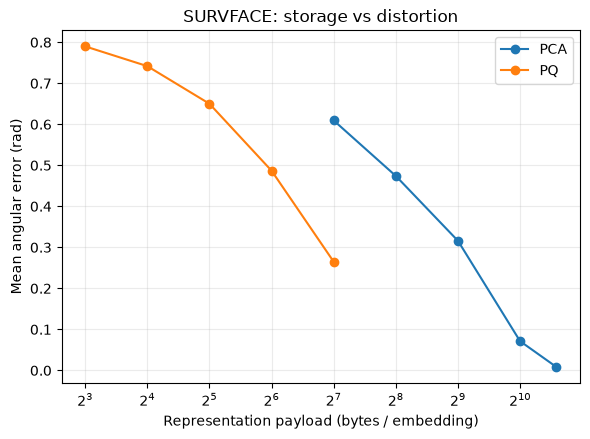

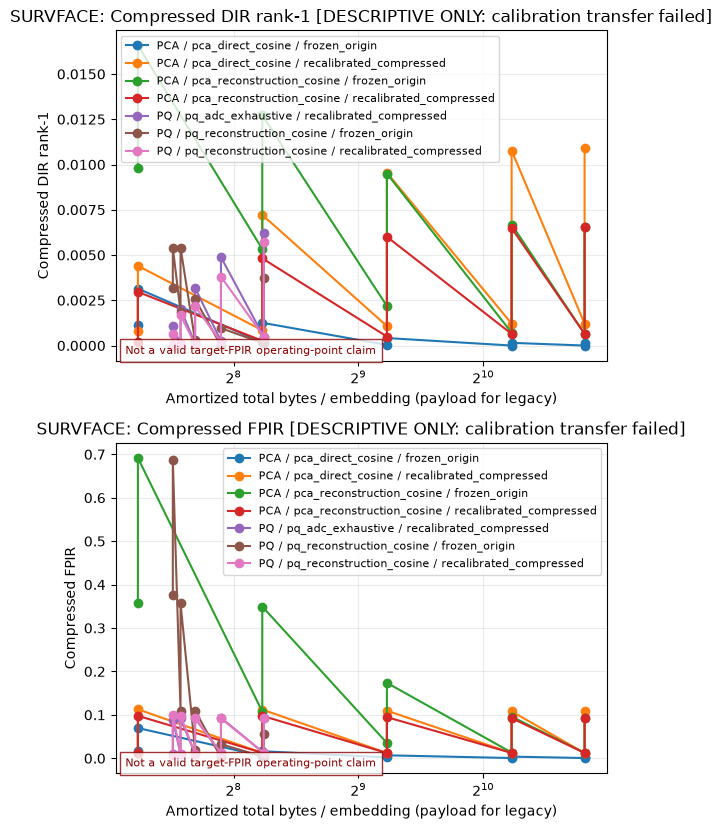

In [21]:
import matplotlib.pyplot as plt

figures = {}
dataset_order = list(DATASETS)

fig_distortion, axes = plt.subplots(
    1, len(dataset_order), figsize=(6 * len(dataset_order), 4.5), squeeze=False
)
geometry = compression_summary_all.drop_duplicates(
    ["dataset", "compression_family", "compression_profile"]
)
for axis, dataset in zip(axes[0], dataset_order):
    subset = geometry.loc[geometry["dataset"].eq(dataset)]
    for family, group in subset.groupby("compression_family", sort=True):
        ordered = group.sort_values("storage_bytes_per_embedding")
        axis.plot(
            ordered["storage_bytes_per_embedding"],
            ordered["mean_angular_error_rad"],
            marker="o",
            label=family.upper(),
        )
    axis.set_xscale("log", base=2)
    axis.set(
        title=f"{dataset.upper()}: storage vs distortion",
        xlabel="Representation payload (bytes / embedding)",
        ylabel="Mean angular error (rad)",
    )
    axis.grid(alpha=0.25)
    axis.legend()
fig_distortion.tight_layout()
figures["storage_distortion"] = fig_distortion

metrics = (
    ("compressed_dir_rank1", "Compressed DIR rank-1"),
    ("compressed_fpir", "Compressed FPIR"),
)
fig_open_set, axes = plt.subplots(
    len(metrics), len(dataset_order),
    figsize=(6 * len(dataset_order), 4.2 * len(metrics)),
    squeeze=False,
)
for column_index, dataset in enumerate(dataset_order):
    subset = compression_summary_all.loc[
        compression_summary_all["dataset"].eq(dataset)
    ]
    for row_index, (metric, ylabel) in enumerate(metrics):
        axis = axes[row_index, column_index]
        for (family, search_mode, policy), group in subset.groupby(
            ["compression_family", "search_mode", "threshold_policy"], sort=True
        ):
            plot_group = group.copy()
            plot_group["plot_storage_bytes"] = pd.to_numeric(
                plot_group["amortized_storage_bytes_per_gallery_template"],
                errors="coerce",
            ).fillna(plot_group["storage_bytes_per_embedding"])
            ordered = plot_group.sort_values("plot_storage_bytes")
            axis.plot(
                ordered["plot_storage_bytes"],
                ordered[metric],
                marker="o",
                label=f"{family.upper()} / {search_mode} / {policy}",
            )
        axis.set_xscale("log", base=2)
        threshold_claim_blocked = bool(
            dataset == "survface"
            and SURVFACE_CALIBRATION_TRANSFER_FAILED is True
        )
        title_suffix = (
            " [DESCRIPTIVE ONLY: calibration transfer failed]"
            if threshold_claim_blocked
            else ""
        )
        axis.set(
            title=f"{dataset.upper()}: {ylabel}{title_suffix}",
            xlabel="Amortized total bytes / embedding (payload for legacy)",
            ylabel=ylabel,
        )
        if threshold_claim_blocked:
            axis.text(
                0.02, 0.02,
                "Not a valid target-FPIR operating-point claim",
                transform=axis.transAxes, color="darkred", fontsize=8,
                bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "darkred"},
            )
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
fig_open_set.tight_layout()
figures["storage_open_set"] = fig_open_set

integrated_columns = [
    "dataset", "model_uid", "run_id", "summary_artifact_type",
    "summary_claim_status", "derived_evaluation_paper_eligible",
    "compression_family",
    "compression_profile", "search_mode", "threshold_policy",
    "target_fpir",
    "compressed_score_space", "compressed_dir_rank1", "compressed_fpir",
    "origin_false_accept_count", "origin_fpir_denominator", "origin_realized_fpir",
    "compressed_false_accept_count", "compressed_fpir_denominator",
    "compressed_realized_fpir", "origin_fpir_wilson95_low",
    "origin_fpir_wilson95_high", "compressed_fpir_wilson95_low",
    "compressed_fpir_wilson95_high", "origin_dir_rank1_wilson95_low",
    "origin_dir_rank1_wilson95_high", "compressed_dir_rank1_wilson95_low",
    "compressed_dir_rank1_wilson95_high", "compressed_minus_origin_fpir",
    "compressed_minus_origin_fpir_paired_bootstrap95_low",
    "compressed_minus_origin_fpir_paired_bootstrap95_high",
    "compressed_minus_origin_dir_rank1",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_low",
    "compressed_minus_origin_dir_rank1_paired_bootstrap95_high",
    "storage_bytes_per_embedding", "codebook_bytes",
    "gallery_template_count", "compressed_gallery_storage_bytes",
    "amortized_storage_bytes_per_gallery_template",
    "compressed_search_latency_ms_per_query",
    "compressed_search_queries_per_second",
    "accept_to_reject_count", "accept_to_reject_rate",
    "reject_to_accept_count", "reject_to_accept_rate",
]
dir_fpir_storage_latency = compression_summary_all[integrated_columns].copy()
display(dir_fpir_storage_latency)


## 6. RFW-Official supplementary 1:1 verification

RFW-Official은 pair/fold 기반 TAR/FAR/Accuracy/EER artifact입니다. RFW-Custom 1:N open-set 행과 결합하지 않습니다. 같은 물리 RFW population에서 fitted/calibrated한 결과는 same-domain diagnostic이며 strict external-transfer 또는 strict unseen-identity 근거가 아닙니다.


In [22]:
from research.experiments import load_rfw_frozen_codec_evaluation

RFW_EVALUATION = None
RFW_PROFILE_SUMMARY = pd.DataFrame()
RFW_GROUP_SUMMARY = pd.DataFrame()
if RFW_EVALUATION_DIR is not None:
    rfw_dir = Path(RFW_EVALUATION_DIR)
    if not rfw_dir.is_absolute():
        rfw_dir = PROJECT_ROOT / rfw_dir
    RFW_EVALUATION = load_rfw_frozen_codec_evaluation(rfw_dir)
    rfw_manifest = RFW_EVALUATION.manifest
    if rfw_manifest.get("open_set_protocol") is not False:
        raise ValueError("RFW result must remain a 1:1 verification artifact")
    if rfw_manifest.get("codec_fit_on_rfw") is not False:
        raise ValueError("RFW result contains a codec fitted on RFW")
    if str(rfw_manifest.get("model_uid")) not in set(MODEL_UIDS.values()):
        raise ValueError("RFW model UID differs from selected open-set runs")
    RFW_PROFILE_SUMMARY = RFW_EVALUATION.profile_summary.copy()
    RFW_GROUP_SUMMARY = RFW_EVALUATION.group_summary.copy()
    required_rfw_profile_columns = {
        "macro_group_accuracy", "macro_group_eer", "group_accuracy_gap",
        "group_eer_gap", "eer_threshold_policy", "eer_threshold_source",
    }
    missing_rfw_profile = sorted(
        required_rfw_profile_columns - set(RFW_PROFILE_SUMMARY.columns)
    )
    if missing_rfw_profile:
        raise ValueError(f"RFW Official profile EER fields are missing: {missing_rfw_profile}")
    required_rfw_group_columns = {
        "mean_tar", "mean_far", "mean_eer", "eer_ci95_low", "eer_ci95_high",
    }
    missing_rfw_group = sorted(
        required_rfw_group_columns - set(RFW_GROUP_SUMMARY.columns)
    )
    if missing_rfw_group:
        raise ValueError(f"RFW Official group TAR/FAR/EER fields are missing: {missing_rfw_group}")
    if not RFW_PROFILE_SUMMARY["open_set_protocol"].eq(False).all():
        raise ValueError("RFW profile summary escaped the 1:1 protocol boundary")
display(RFW_PROFILE_SUMMARY)
display(RFW_GROUP_SUMMARY)


""


""


## 7. SurvFace Grad-CAM faithfulness (matched checkpoint condition)

모델별 checkpoint와 동일한 source run을 검증한 high/low/random occlusion artifact만 포함합니다. 모델 family의 인과효과가 아니라 checkpoint-level 결과입니다.

In [23]:
SURVFACE_FAITHFULNESS = pd.DataFrame()
SURVFACE_FAITHFULNESS_MANIFEST = None
SURVFACE_FAITHFULNESS_DIR = (
    PROJECT_ROOT / "results/paper/survface/faithfulness_cross_model_v1"
)
if INCLUDE_SURVFACE_FAITHFULNESS and "survface" in DATASETS:
    faithfulness_manifest_path = SURVFACE_FAITHFULNESS_DIR / "manifest.json"
    faithfulness_table_path = (
        SURVFACE_FAITHFULNESS_DIR / "faithfulness_cross_model_primary.csv"
    )
    SURVFACE_FAITHFULNESS_MANIFEST = load_json(faithfulness_manifest_path)
    if SURVFACE_FAITHFULNESS_MANIFEST.get("artifact_type") != (
        "survface_gradcam_faithfulness_cross_model"
    ):
        raise ValueError("unexpected SurvFace faithfulness artifact type")
    if SURVFACE_FAITHFULNESS_MANIFEST.get("threshold_independent") is not True:
        raise ValueError("SurvFace faithfulness must be threshold-independent")
    selected_source_matches = [
        source for source in SURVFACE_FAITHFULNESS_MANIFEST.get("sources", [])
        if source.get("source_run_id") == SELECTED_RUN_IDS["survface"]
        and source.get("model_uid") == MODEL_UIDS["survface"]
    ]
    if len(selected_source_matches) != 1:
        print(
            "WARNING: selected SurvFace run/model is absent from the "
            "cross-model faithfulness artifact; faithfulness is excluded."
        )
        SURVFACE_FAITHFULNESS_MANIFEST = None
    else:
        output_entry = next(
            entry for entry in SURVFACE_FAITHFULNESS_MANIFEST["outputs"]
            if entry["path"] == faithfulness_table_path.name
        )
        if sha256_file(faithfulness_table_path) != output_entry["sha256"]:
            raise ValueError("SurvFace faithfulness table SHA-256 mismatch")
        SURVFACE_FAITHFULNESS = pd.read_csv(faithfulness_table_path)
        faithfulness_families = set(SURVFACE_FAITHFULNESS["model_family"])
        baseline_families = {"arcface", "adaface", "magface"}
        if (
            not baseline_families.issubset(faithfulness_families)
            or not faithfulness_families <= baseline_families | {"edgeface"}
        ):
            raise ValueError(
                "SurvFace faithfulness requires the baseline trio and may add EdgeFace"
            )
display(SURVFACE_FAITHFULNESS)


""


## 8. 공통 CSV·그림·manifest 저장

compact table, LFW·SurvFace FPIR appendix, 그림과 lineage manifest만 기록합니다. 대용량 query/sample ledger는 복제하지 않습니다.


In [24]:
from datetime import datetime, timezone

selection_tag = "__".join(
    f"{dataset}-{SELECTED_RUN_IDS[dataset]}" for dataset in DATASETS
)
COMMON_OUTPUT_DIR = (
    PROJECT_ROOT / "results" / "paper" / "common" / MODEL_NAME / selection_tag
)
export_result = {
    "status": "computed_not_written",
    "destination": COMMON_OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix(),
    "compression_summary_all_rows": int(len(compression_summary_all)),
    "saliency_geometry_association_rows": int(len(SALIENCY_GEOMETRY_ALL)),
    "saliency_retrieval_association_rows": int(len(SALIENCY_RETRIEVAL_ALL)),
    "representative_case_rows": int(len(REPRESENTATIVE_CASES_ALL)),
}

if WRITE_OUTPUTS:
    COMMON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_paths = {
        "compression_summary_all.csv": COMMON_OUTPUT_DIR / "compression_summary_all.csv",
        "retrieval_summary_all.csv": COMMON_OUTPUT_DIR / "retrieval_summary_all.csv",
        "saliency_geometry_associations_all.csv": COMMON_OUTPUT_DIR / "saliency_geometry_associations_all.csv",
        "saliency_retrieval_associations_all.csv": COMMON_OUTPUT_DIR / "saliency_retrieval_associations_all.csv",
        "representative_cases_all.csv": COMMON_OUTPUT_DIR / "representative_cases_all.csv",
        "dir_fpir_storage_latency.csv": COMMON_OUTPUT_DIR / "dir_fpir_storage_latency.csv",
        "lfw_survface_fpir_appendix.csv": COMMON_OUTPUT_DIR / "lfw_survface_fpir_appendix.csv",
        "storage_distortion.png": COMMON_OUTPUT_DIR / "storage_distortion.png",
        "storage_open_set.png": COMMON_OUTPUT_DIR / "storage_open_set.png",
    }
    if not SURVFACE_FAITHFULNESS.empty:
        output_paths["survface_faithfulness_cross_model.csv"] = (
            COMMON_OUTPUT_DIR / "survface_faithfulness_cross_model.csv"
        )
    if not RFW_PROFILE_SUMMARY.empty:
        output_paths["rfw_profile_summary.csv"] = (
            COMMON_OUTPUT_DIR / "rfw_profile_summary.csv"
        )
        output_paths["rfw_group_summary.csv"] = (
            COMMON_OUTPUT_DIR / "rfw_group_summary.csv"
        )
    existing = [path for path in output_paths.values() if path.exists()]
    manifest_path = COMMON_OUTPUT_DIR / "cross_dataset_summary_manifest.json"
    if manifest_path.exists():
        existing.append(manifest_path)
    if existing and not OVERWRITE_COMMON_OUTPUTS:
        raise FileExistsError(
            f"공통 출력이 이미 있습니다. OVERWRITE_COMMON_OUTPUTS=True가 필요합니다: {existing}"
        )

    compression_summary_all.to_csv(
        output_paths["compression_summary_all.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    retrieval_summary_all.to_csv(
        output_paths["retrieval_summary_all.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    SALIENCY_GEOMETRY_ALL.to_csv(
        output_paths["saliency_geometry_associations_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    SALIENCY_RETRIEVAL_ALL.to_csv(
        output_paths["saliency_retrieval_associations_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    REPRESENTATIVE_CASES_ALL.to_csv(
        output_paths["representative_cases_all.csv"],
        index=False, encoding="utf-8", lineterminator="\n",
        float_format="%.12g",
    )
    dir_fpir_storage_latency.to_csv(
        output_paths["dir_fpir_storage_latency.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    lfw_survface_fpir_appendix.to_csv(
        output_paths["lfw_survface_fpir_appendix.csv"],
        index=False,
        encoding="utf-8",
        lineterminator="\n",
        float_format="%.12g",
    )
    if not SURVFACE_FAITHFULNESS.empty:
        SURVFACE_FAITHFULNESS.to_csv(
            output_paths["survface_faithfulness_cross_model.csv"],
            index=False,
            encoding="utf-8",
            lineterminator="\n",
            float_format="%.12g",
        )
    if not RFW_PROFILE_SUMMARY.empty:
        RFW_PROFILE_SUMMARY.to_csv(
            output_paths["rfw_profile_summary.csv"],
            index=False, encoding="utf-8", lineterminator="\n",
            float_format="%.12g",
        )
        RFW_GROUP_SUMMARY.to_csv(
            output_paths["rfw_group_summary.csv"],
            index=False, encoding="utf-8", lineterminator="\n",
            float_format="%.12g",
        )
    figures["storage_distortion"].savefig(
        output_paths["storage_distortion.png"], dpi=180, bbox_inches="tight"
    )
    figures["storage_open_set"].savefig(
        output_paths["storage_open_set.png"], dpi=180, bbox_inches="tight"
    )

    common_manifest = {
        "schema_version": 8,
        "artifact_type": "cross_dataset_results",
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "model_name": MODEL_NAME,
        "datasets": list(DATASETS),
        "comparison_unit": "pretrained_checkpoint",
        "causal_loss_claim": False,
        "confidence_interval_contract": {
            "unit": "probe",
            "rates": "two-sided Wilson score 95%",
            "compressed_minus_origin": (
                "paired nonparametric bootstrap percentile 95%; 2000 repeats; seed 42"
            ),
            "does_not_cover": ["identity_cluster", "checkpoint_training_uncertainty"],
        },
        "rfw_custom_boundary": {
            "protocol": "custom_1_to_n_open_set_identification",
            "official_result_eligible": False,
            "checkpoint_overlap_status": "UNKNOWN",
            "strict_unseen_identity_evidence": False,
        },
        "deferred_work": [
            "faiss_ivf_pq", "pgvector_ivfflat", "ann_parameter_sweep",
            "balancedface", "uncertainty_defer_high_low_risk_queries",
        ],
        "survface_threshold_claim_status": (
            "blocked_calibration_transfer"
            if SURVFACE_CALIBRATION_TRANSFER_FAILED is True
            else "not_flagged"
        ),
        "selected_runs": {
            dataset: {
                "run_id": SELECTED_RUN_IDS[dataset],
                "model_uid": MODEL_UIDS[dataset],
                "run_dir": SELECTED_RUNS[dataset].relative_to(PROJECT_ROOT).as_posix(),
                "summary_artifact_type": SUMMARY_MANIFESTS[dataset]["artifact_type"],
                "summary_claim_status": SUMMARY_MANIFESTS[dataset].get(
                    "claim_status", "legacy_source_run"
                ),
                "summary_manifest": {
                    "path": (
                        SUMMARY_DIRS[dataset] / "summary_manifest.json"
                    ).relative_to(PROJECT_ROOT).as_posix(),
                    "sha256": sha256_file(
                        SUMMARY_DIRS[dataset] / "summary_manifest.json"
                    ),
                },
            }
            for dataset in DATASETS
        },
        "saliency_associations": {
            "included": True,
            "geometry_rows": int(len(SALIENCY_GEOMETRY_ALL)),
            "retrieval_rows": int(len(SALIENCY_RETRIEVAL_ALL)),
            "representative_case_rows": int(len(REPRESENTATIVE_CASES_ALL)),
            "bootstrap_unit": "identity_id",
            "source_files": SALIENCY_ASSOCIATIONS.source_files,
        },
        "rfw_verification": (
            {
                "included": True,
                "evaluation_role": "supplementary_1to1_verification",
                "open_set_protocol": False,
                "codec_fit_on_rfw": False,
                "model_uid": RFW_EVALUATION.manifest["model_uid"],
                "codec_count": len(RFW_EVALUATION.manifest.get("codecs", [])),
                "source_manifest": {
                    "path": str(RFW_EVALUATION.root / "rfw_frozen_codec_manifest.json"),
                    "sha256": sha256_file(
                        RFW_EVALUATION.root / "rfw_frozen_codec_manifest.json"
                    ),
                },
            }
            if RFW_EVALUATION is not None
            else {"included": False}
        ),
        "survface_faithfulness": (
            {
                "included": True,
                "claim_status": SURVFACE_FAITHFULNESS_MANIFEST["claim_status"],
                "paper_eligible": SURVFACE_FAITHFULNESS_MANIFEST["paper_eligible"],
                "threshold_independent": True,
                "strong_faithfulness_pass_count": (
                    SURVFACE_FAITHFULNESS_MANIFEST["strong_faithfulness_pass_count"]
                ),
                "source_manifest": {
                    "path": (
                        SURVFACE_FAITHFULNESS_DIR / "manifest.json"
                    ).relative_to(PROJECT_ROOT).as_posix(),
                    "sha256": sha256_file(
                        SURVFACE_FAITHFULNESS_DIR / "manifest.json"
                    ),
                },
            }
            if SURVFACE_FAITHFULNESS_MANIFEST is not None
            else {"included": False}
        ),
        "cross_model_open_set_matrix": (
            {
                "included": True,
                "matrix_uid": CROSS_MODEL_SELECTION_MANIFEST["matrix_uid"],
                "complete_matrix": True,
                "model_families": CROSS_MODEL_SELECTION_MANIFEST[
                    "model_families"
                ],
                "open_set_datasets": CROSS_MODEL_SELECTION_MANIFEST[
                    "open_set_datasets"
                ],
                "interpretation": "checkpoint_level_generalization",
            }
            if CROSS_MODEL_SELECTION_MANIFEST is not None
            else {"included": False}
        ),
        "join_contract": {
            "grain": (
                "one row per dataset, model, run, compression profile, "
                "search mode, threshold policy, and target FPIR"
            ),
            "validation": "compression one-to-retrieval many",
            "rows": int(len(compression_summary_all)),
        },
        "output_files": {
            name: {
                "path": path.relative_to(PROJECT_ROOT).as_posix(),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for name, path in output_paths.items()
        },
    }
    manifest_path.write_text(
        json.dumps(common_manifest, ensure_ascii=False, indent=2, sort_keys=True)
        + "\n",
        encoding="utf-8",
        newline="\n",
    )
    export_result = {
        "status": "written",
        "destination": COMMON_OUTPUT_DIR.relative_to(PROJECT_ROOT).as_posix(),
        "manifest": manifest_path.relative_to(PROJECT_ROOT).as_posix(),
        "compression_summary_all_rows": int(len(compression_summary_all)),
        "retrieval_summary_all_rows": int(len(retrieval_summary_all)),
        "saliency_geometry_association_rows": int(len(SALIENCY_GEOMETRY_ALL)),
        "saliency_retrieval_association_rows": int(len(SALIENCY_RETRIEVAL_ALL)),
        "representative_case_rows": int(len(REPRESENTATIVE_CASES_ALL)),
    }
if CROSS_MODEL_MATRIX is None:
    export_result["cross_model_matrix"] = {"status": "not_configured"}
elif WRITE_OUTPUTS:
    matrix_write = write_cross_model_open_set_matrix(
        CROSS_MODEL_MATRIX,
        PROJECT_ROOT / "results/paper/common/four_model_three_dataset",
        overwrite=OVERWRITE_COMMON_OUTPUTS,
    )
    export_result["cross_model_matrix"] = {
        "status": "written",
        "matrix_uid": CROSS_MODEL_SELECTION_MANIFEST["matrix_uid"],
        "destination": matrix_write.output_dir.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "manifest": matrix_write.manifest_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
    }
else:
    export_result["cross_model_matrix"] = {
        "status": "validated_not_written",
        "matrix_uid": CROSS_MODEL_SELECTION_MANIFEST["matrix_uid"],
        "joined_rows": int(len(CROSS_MODEL_JOINED)),
    }
export_result


{'status': 'written',
 'destination': 'results/paper/common/arcface/survface-20260810-R001-5d742943',
 'manifest': 'results/paper/common/arcface/survface-20260810-R001-5d742943/cross_dataset_summary_manifest.json',
 'compression_summary_all_rows': 70,
 'retrieval_summary_all_rows': 70,
 'saliency_geometry_association_rows': 570,
 'saliency_retrieval_association_rows': 7980,
 'representative_case_rows': 953,
 'cross_model_matrix': {'status': 'not_configured'}}

## Final check

- 세 open-set dataset은 protocol UID와 population이 다르며 절대 DIR/FPIR 난이도를 동일시하지 않습니다.
- 모든 compact 행은 FPIR 10%/1%, false accept 수·분모·realized FPIR, Wilson CI와 paired delta CI를 보존합니다.
- source ledger의 `origin_fallback_used`는 compact `origin_fallback_count=0`으로 재검증합니다.
- `frozen_origin`과 `recalibrated_compressed`를 분리하고 PCA direct/reconstruction 및 PQ reconstruction/ADC를 합치지 않습니다.
- CI는 probe-level이며 checkpoint 재학습 불확실성이 아닙니다.
- ArcFace·AdaFace·MagFace·EdgeFace 결과는 checkpoint-level 비교입니다.
- 4×3 통합 표는 `MODEL_RUN_MATRIX`에 명시된 12개 완료 run이 모두 검증된 경우에만 생성합니다.
- EdgeFace–RFW overlap은 `UNKNOWN`; RFW는 strict unseen-identity evidence가 아닙니다.
- RFW-Custom 1:N과 RFW-Official 1:1 TAR/FAR/EER는 별도 artifact와 표로 유지합니다.
- IVF-PQ, pgvector IVFFlat, ANN sweep, BalancedFace, uncertainty/defer는 유예 상태입니다.
